In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the cleaned data
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

In [3]:
#creating timeseries data by grouping by invoice year-month and summing total price and not by date because there are multiple transactions in a day and we want to see the trend over time and not daily fluctuations
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['InvoiceYearMonth'] = df['InvoiceDate'].dt.to_period('M')
timeseries_data = df.groupby('InvoiceYearMonth')['TotalPrice'].sum().reset_index()  
timeseries_data['InvoiceYearMonth'] = timeseries_data['InvoiceYearMonth'].dt.to_timestamp()
timeseries_data.head()


,InvoiceYearMonth,TotalPrice
0,2009-12-01,683504.010
1,2010-01-01,555802.672
2,2010-02-01,504558.956
3,2010-03-01,696978.471
4,2010-04-01,591982.002


In [4]:
#remobing date from InvoiceYearMonth column and keeping only year and month for better visualization
timeseries_data['InvoiceYearMonth'] = timeseries_data['InvoiceYearMonth'].dt.strftime('%Y-%m')
timeseries_data.head()

,InvoiceYearMonth,TotalPrice
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002


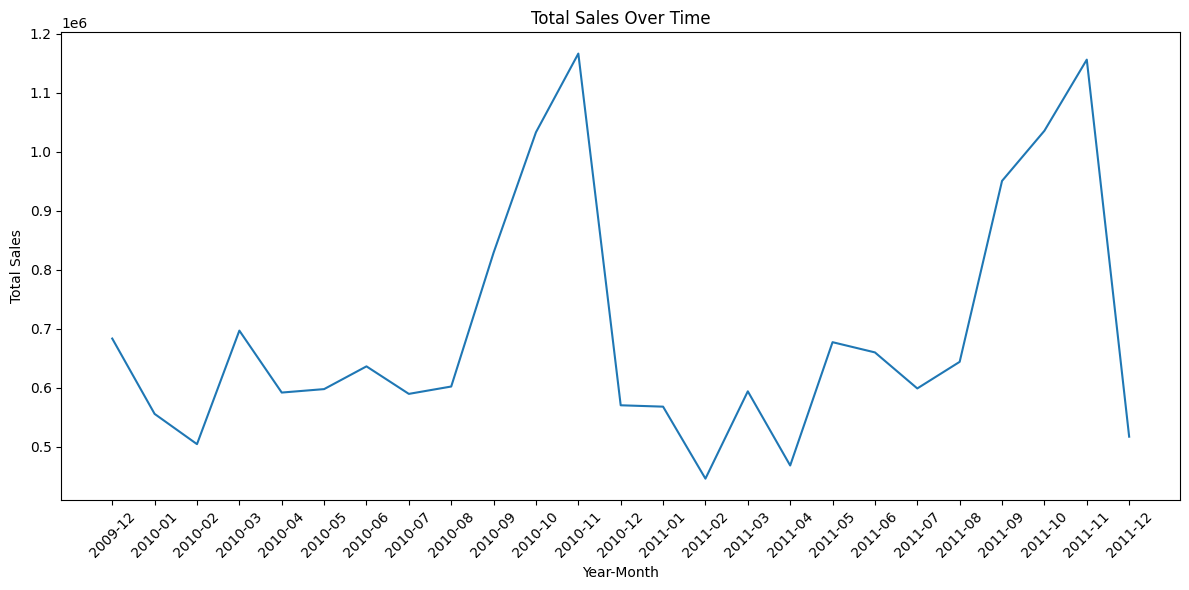

In [5]:
#line plot of total sales over time
plt.figure(figsize=(12,6))
sns.lineplot(data=timeseries_data, x='InvoiceYearMonth', y='TotalPrice')
plt.xticks(rotation=45)
plt.title('Total Sales Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [6]:
#count months
print("Number of months in the dataset:", timeseries_data['InvoiceYearMonth'].nunique())

Number of months in the dataset: 25


In [7]:
#create monthly revenue series sorted chronologically
monthly_revenue = timeseries_data.sort_values('InvoiceYearMonth')
monthly_revenue.set_index('InvoiceYearMonth', inplace=True)
monthly_revenue.head()

,TotalPrice
InvoiceYearMonth,
2009-12,683504.010
2010-01,555802.672
2010-02,504558.956
2010-03,696978.471
2010-04,591982.002


In [8]:
#train test split with last 5 months as test set and rest as train set
train = monthly_revenue[:-5]
test = monthly_revenue[-5:]
print("Train set shape:", train.shape)
print("Test set shape:", test.shape)

Train set shape: (20, 1)
Test set shape: (5, 1)


In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

final_model = ExponentialSmoothing(
    monthly_revenue,
    trend="add",
    seasonal=None
).fit()

c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [10]:
forecast = final_model.forecast(steps=6)

In [11]:
start = pd.to_datetime(monthly_revenue.index.max(), format="%Y-%m") + pd.offsets.MonthBegin(1)
future_months = pd.date_range(start=start, periods=6, freq="MS")

In [12]:
forecast_df = pd.DataFrame({
    "forecast_month": future_months,
    "predicted_revenue": forecast.values,
    "model_name": "Holt-Winters"
})

In [13]:
print(forecast_df.dtypes)

forecast_month       datetime64[ns]
predicted_revenue           float64
model_name                   object
dtype: object


In [13]:
forecast_df.to_csv(
    "../data/processed/sales_forecast.csv",
    index=False
)

In [8]:
#create baseline model  
baseline_pred = train['TotalPrice'].iloc[-1]
test['Baseline_Prediction'] = baseline_pred
print(test)

                   TotalPrice  Baseline_Prediction
InvoiceYearMonth                                  
2011-08            644051.040           598962.901
2011-09            950690.202           598962.901
2011-10           1035642.450           598962.901
2011-11           1156205.610           598962.901
2011-12            517208.440           598962.901


C:\Users\sania\AppData\Local\Temp\ipykernel_8548\3579282522.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Baseline_Prediction'] = baseline_pred


In [9]:
#calculate baseline MAE
from sklearn.metrics import mean_absolute_error
baseline_mae = mean_absolute_error(test['TotalPrice'], test['Baseline_Prediction'])
print("Baseline MAE:", baseline_mae)

Baseline MAE: 294498.4318


In [10]:
%pip install statsmodels
from statsmodels.tsa.holtwinters import ExponentialSmoothing

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
model = ExponentialSmoothing(
    train,
    trend="add"
)

fit_model = model.fit()

c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [12]:
forecast = fit_model.forecast(len(test))

forecast

2011-08-01    613706.563549
2011-09-01    614537.460188
2011-10-01    615368.356827
2011-11-01    616199.253467
2011-12-01    617030.150106
Freq: MS, dtype: float64

In [13]:
mae = mean_absolute_error(test['TotalPrice'], forecast)

print("MAE:", round(mae, 2))

MAE: 285319.88


In [14]:
from statsmodels.tsa.arima.model import ARIMA

In [15]:
model = ARIMA(
    train,
    order=(1,1,1)
)

fit_model = model.fit()

c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [16]:
forecast = fit_model.forecast(
    steps=len(test)
)

forecast

2011-08-01    607093.804487
2011-09-01    611516.948701
2011-10-01    613923.102553
2011-11-01    615232.030337
2011-12-01    615944.076220
Freq: MS, Name: predicted_mean, dtype: float64

In [17]:
mae = mean_absolute_error(test['TotalPrice'], forecast)

print("MAE:", round(mae, 2))

MAE: 287511.81


In [18]:
import joblib
joblib.dump(
    fit_model,
    "../models/forecasting/holt_winters.pkl"
)

['../models/forecasting/holt_winters.pkl']